# Nevoscan - приложение для анализа дерматоскопических изображений: классификация клинических признаков
## Преддипломная практика
Газизуллина Камилла, КНАД 222

**Задача:** multi-label классификация 7 клинических признаков по шкале Argenziano  
**Датасет:** 7-point criteria evaluation dataset (Kawahara et al.)  
**Архитектуры:** EfficientNet-B0, EfficientNet-B3  
**Loss:** Focal Loss

In [ ]:
import torch
print("CUDA доступна:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA доступна: True
GPU: NVIDIA L4


### 1. Подключение датасета и импорт необходимых библиотек

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/Диплом/практика_преддипломная/derm7pt.zip" -d "/content/dataset"
!git clone https://github.com/jeremykawahara/derm7pt.git
print("Готово!")

Mounted at /content/drive
Cloning into 'derm7pt'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 125 (delta 9), reused 24 (delta 6), pack-reused 92 (from 1)
Receiving objects: 100% (125/125), 406.66 KiB | 29.05 MiB/s, done.
Resolving deltas: 100% (52/52), done.
Готово!


In [ ]:
!pip install timm -q

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score
)

# Воспроизводимость
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

Используем устройство: cuda


### 2. Конфигурация

In [ ]:
# Пути
BASE_DIR  = "/content/dataset/release_v0"
IMG_DIR   = os.path.join(BASE_DIR, "images")
META_PATH = os.path.join(BASE_DIR, "meta/meta.csv")

# Признаки по системе Argenziano
FEATURES = [
    'pigment_network',
    'streaks',
    'pigmentation',
    'regression_structures',
    'dots_and_globules',
    'blue_whitish_veil',
    'vascular_structures'
]

FEATURE_NAMES_RU = [
    'Пигментная сеть',
    'Полосы (Streaks)',
    'Пигментация',
    'Регрессия',
    'Точки/Глобулы',
    'Бело-голубая вуаль',
    'Сосудистые структуры'
]

# Гиперпараметры
EPOCHS     = 12
BATCH_SIZE = 16
LR         = 1e-4
THRESHOLD  = 0.4
print("Конфигурация загружена.")

Конфигурация загружена.


### 3. Загрузка и бинаризация разметки

In [ ]:
def map_feature(text):
    # 0 - норма, 1 - патология
    if pd.isna(text):
        return 0
    text = str(text).lower().strip()
    return 0 if text in ['absent', 'regular', 'typical'] else 1


# поиск необходимых файлов
print("Сканируем диск...")
all_files = glob.glob(os.path.join(IMG_DIR, "**/*"), recursive=True)
path_map  = {f.lower(): f for f in all_files if os.path.isfile(f)}

def find_path(derm_path):
    key = os.path.join(IMG_DIR, derm_path).lower().replace("\\", "/")
    return path_map.get(key)


df = pd.read_csv(META_PATH)

df_bin = df.copy()
for feat in FEATURES:
    df_bin[feat] = df_bin[feat].apply(map_feature)

df_bin['full_path'] = df_bin['derm'].apply(find_path)
df_bin = df_bin.dropna(subset=['full_path']).reset_index(drop=True)

print(f"Итого записей с найденными изображениями: {len(df_bin)}")
print(df_bin[FEATURES].head())

Сканируем диск...
Итого записей с найденными изображениями: 1011
   pigment_network  streaks  pigmentation  regression_structures  \
0                0        0             0                      0   
1                0        0             0                      0   
2                0        0             0                      0   
3                0        0             0                      1   
4                0        0             1                      0   

   dots_and_globules  blue_whitish_veil  vascular_structures  
0                  0                  0                    1  
1                  1                  0                    0  
2                  1                  0                    1  
3                  1                  1                    1  
4                  0                  0                    0  


### 4. Разведочный анализ данных (EDA)

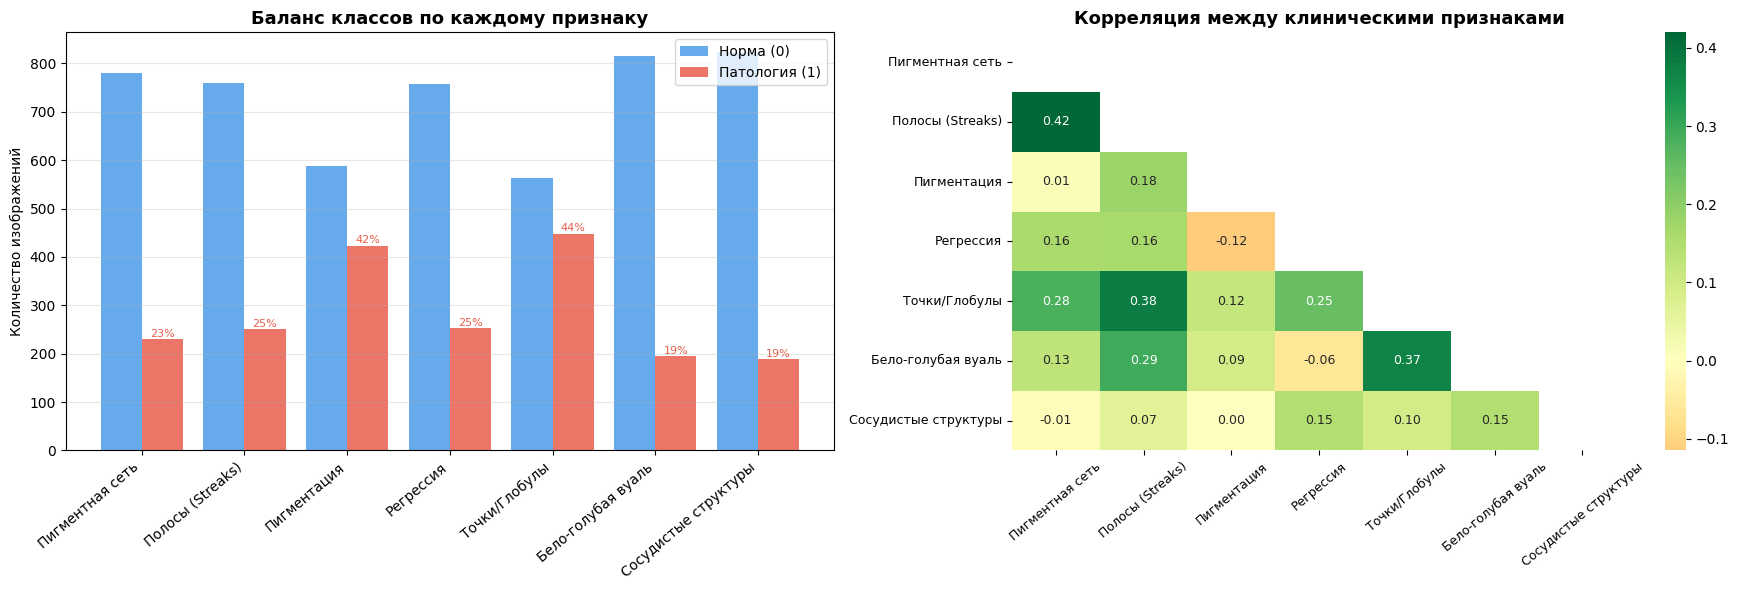

EDA сохранён в eda_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Баланс классов
counts_pos = df_bin[FEATURES].sum()
counts_neg = len(df_bin) - counts_pos

x = np.arange(len(FEATURES))
width = 0.4
axes[0].bar(x - width/2, counts_neg, width, label='Норма (0)', color='#4C9BE8', alpha=0.85)
axes[0].bar(x + width/2, counts_pos, width, label='Патология (1)', color='#E85D4C', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(FEATURE_NAMES_RU, rotation=40, ha='right', fontsize=10)
axes[0].set_title('Баланс классов по каждому признаку', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Количество изображений')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Добавляем % над столбцами
for i, (neg, pos) in enumerate(zip(counts_neg, counts_pos)):
    pct = pos / (pos + neg) * 100
    axes[0].text(i + width/2, pos + 5, f'{pct:.0f}%', ha='center', fontsize=8, color='#E85D4C')

# Корреляционная матрица
corr = df_bin[FEATURES].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=axes[1],
    xticklabels=FEATURE_NAMES_RU,
    yticklabels=FEATURE_NAMES_RU,
    annot_kws={'size': 9}
)
axes[1].set_title('Корреляция между клиническими признаками', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=40, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA сохранён в eda_analysis.png")

### 5. Посмотрим примеры изображений из датасета

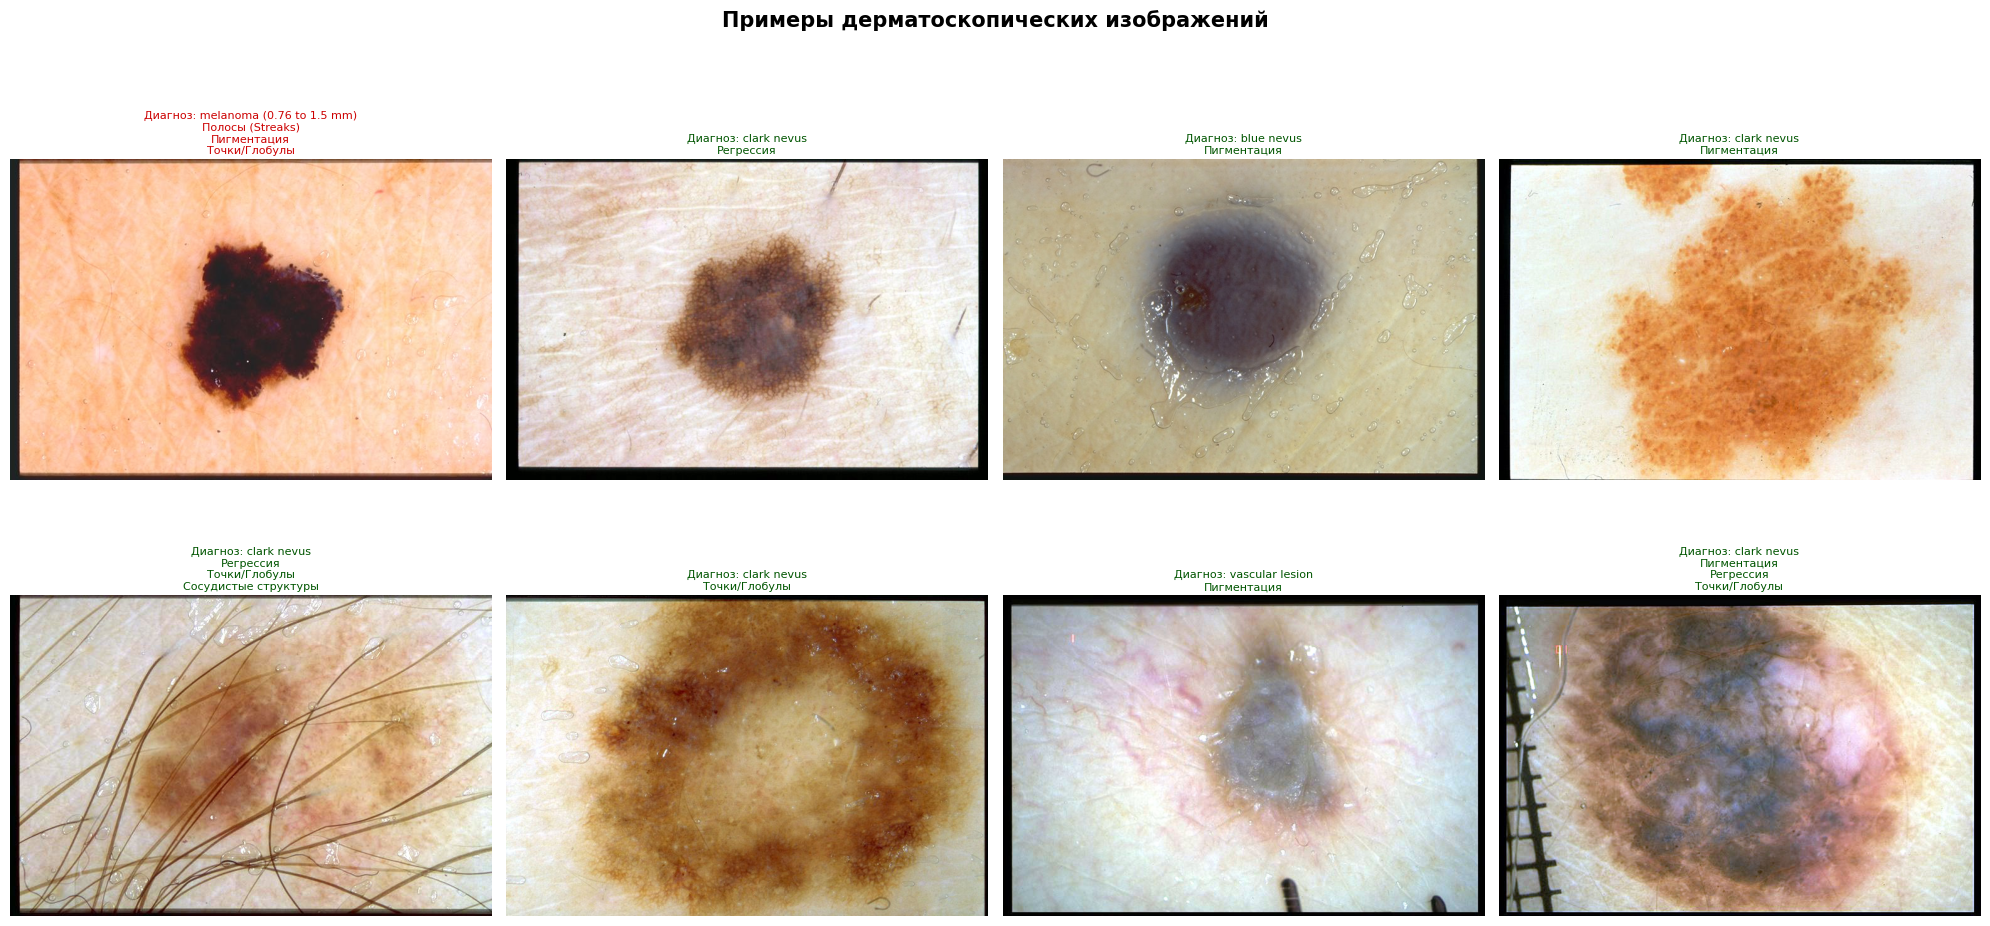

Примеры сохранены в sample_images.png


In [ ]:
def show_samples(df, n=8, title='Примеры дерматоскопических изображений'):
    # Берём случайные изображения с хотя бы одной патологией
    pool = df[df[FEATURES].sum(axis=1) > 0].sample(min(n, len(df)), random_state=SEED)

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)

    for ax, (_, row) in zip(axes.flat, pool.iterrows()):
        img = Image.open(row['full_path']).convert('RGB')
        ax.imshow(img)
        ax.axis('off')

        present = [FEATURE_NAMES_RU[i] for i, f in enumerate(FEATURES) if row[f] == 1]
        diag = row.get('diagnosis', '?')
        color = '#CC0000' if 'melanoma' in str(diag).lower() else '#005500'
        label = f"Диагноз: {diag}\n" + "\n".join(present) if present else f"Диагноз: {diag}\n(нет признаков)"
        ax.set_title(label, fontsize=8, color=color, pad=4)

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Примеры сохранены в sample_images.png")

show_samples(df_bin)

### 6. Разбиваем данные на train / val / test

In [ ]:
def load_split(csv_name):
    idx = pd.read_csv(os.path.join(BASE_DIR, f"meta/{csv_name}")).iloc[:, 0].values
    valid_idx = [i for i in idx if i < len(df_bin) and df_bin.iloc[i]['full_path'] is not None]
    return df_bin.iloc[valid_idx].copy().reset_index(drop=True)

train_df = load_split('train_indexes.csv')
val_df   = load_split('valid_indexes.csv')
test_df  = load_split('test_indexes.csv')

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Проверяем распределение позитивных меток в каждой выборке
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pos_rate = split_df[FEATURES].mean()
    print(f"\n{split_name} — доля позитивных:")
    for feat, ru, val in zip(FEATURES, FEATURE_NAMES_RU, pos_rate):
        print(f"  {ru:<30} {val:.2%}")

Train: 413 | Val: 203 | Test: 395

Train — доля позитивных:
  Пигментная сеть                22.52%
  Полосы (Streaks)               24.46%
  Пигментация                    38.74%
  Регрессия                      23.24%
  Точки/Глобулы                  41.89%
  Бело-голубая вуаль             17.92%
  Сосудистые структуры           15.98%

Val — доля позитивных:
  Пигментная сеть                21.67%
  Полосы (Streaks)               27.59%
  Пигментация                    44.83%
  Регрессия                      25.12%
  Точки/Глобулы                  48.28%
  Бело-голубая вуаль             22.66%
  Сосудистые структуры           19.70%

Test — доля позитивных:
  Пигментная сеть                23.54%
  Полосы (Streaks)               23.80%
  Пигментация                    43.54%
  Регрессия                      26.84%
  Точки/Глобулы                  44.81%
  Бело-голубая вуаль             18.99%
  Сосудистые структуры           20.76%


### 7. Dataset и DataLoader

In [ ]:
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        labels = torch.tensor(row[FEATURES].values.astype('float32'))
        if self.transform:
            image = self.transform(image)
        return image, labels


def make_transforms(img_size):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    return train_tf, val_tf


def make_loaders(train_df, val_df, img_size, batch_size=BATCH_SIZE):
    train_tf, val_tf = make_transforms(img_size)
    train_loader = DataLoader(
        SkinDataset(train_df, train_tf), batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        SkinDataset(val_df, val_tf), batch_size=batch_size,
        shuffle=False, num_workers=2, pin_memory=True
    )
    return train_loader, val_loader

print("Dataset и DataLoader определены.")

Dataset и DataLoader определены.


### 8. Focal Loss

In [ ]:
class FocalLoss(nn.Module):
    # FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt  = torch.exp(-bce) # вероятность правильного класса
        fl  = self.alpha * (1 - pt) ** self.gamma * bce
        return fl.mean()

print("FocalLoss определён.")

FocalLoss определён.


### 9. Функция обучения одной эпохи

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item()
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy())
    preds  = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    return total_loss / len(loader), preds, labels


def compute_metrics(preds_proba, labels, threshold=THRESHOLD):
    # Считаем F1, AUC-ROC, Precision, Recall для каждого признака
    preds_bin = (preds_proba >= threshold).astype(int)
    results = {}
    for i, (feat, ru) in enumerate(zip(FEATURES, FEATURE_NAMES_RU)):
        y_true = labels[:, i]
        y_pred = preds_bin[:, i]
        y_prob = preds_proba[:, i]
        # AUC только если оба класса присутствуют
        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = float('nan')
        results[feat] = {
            'name_ru':   ru,
            'f1':        f1_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall':    recall_score(y_true, y_pred, zero_division=0),
            'auc':       auc,
            'support':   int(y_true.sum())
        }
    return results

print("Функции обучения и оценки определены.")

Функции обучения и оценки определены.


### 10. Визуализация кривых обучения

In [ ]:
def plot_loss_curves(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Кривые обучения — {model_name}', fontsize=14, fontweight='bold')

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#4C9BE8', label='Train Loss', linewidth=2)
    axes[0].plot(epochs_range, history['val_loss'],   's--', color='#E85D4C', label='Val Loss',   linewidth=2)
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Focal Loss')
    axes[0].set_title('Loss по эпохам')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    # Отметим минимальный val loss
    best_ep = np.argmin(history['val_loss'])
    axes[0].axvline(best_ep + 1, color='gray', linestyle=':', label=f'Best val (ep {best_ep+1})')
    axes[0].legend()

    # Macro F1 по эпохам
    if 'val_macro_f1' in history:
        axes[1].plot(epochs_range, history['val_macro_f1'], '^-', color='#28A745', linewidth=2)
        axes[1].set_xlabel('Эпоха')
        axes[1].set_ylabel('Macro F1')
        axes[1].set_title('Macro F1 на валидации')
        axes[1].set_ylim(0, 1)
        axes[1].grid(alpha=0.3)
        axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline 0.5')
        axes[1].legend()
    else:
        axes[1].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Функция визуализации определена.")

Функция визуализации определена.


### 11. Confusion Matrix для каждого признака

In [ ]:
def plot_confusion_matrices(preds_proba, labels, model_name, threshold=THRESHOLD, save_path=None):
    preds_bin = (preds_proba >= threshold).astype(int)

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(f'Confusion Matrices — {model_name} (threshold={threshold})',
                 fontsize=14, fontweight='bold')

    for i, (feat, ru) in enumerate(zip(FEATURES, FEATURE_NAMES_RU)):
        ax = axes[i // 4][i % 4]
        cm = confusion_matrix(labels[:, i], preds_bin[:, i])
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Патология'],
            yticklabels=['Норма', 'Патология'],
            cbar=False
        )
        f1  = f1_score(labels[:, i], preds_bin[:, i], zero_division=0)
        rec = recall_score(labels[:, i], preds_bin[:, i], zero_division=0)
        ax.set_title(f'{ru}\nF1={f1:.2f}  Recall={rec:.2f}', fontsize=9)
        ax.set_xlabel('Предсказание')
        ax.set_ylabel('Истина')

    axes[1][3].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Функция confusion matrix определена.")

Функция confusion matrix определена.


### 12. Grad-CAM

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score  = output[0, class_idx] # логит нужного признака
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True) # GAP по пространству
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = cam.squeeze().cpu().numpy()

        # Нормализация в [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def get_target_layer(model, model_name):
    # Возвращает последний сверточный блок для EfficientNet из timm
    if 'efficientnet' in model_name:
        return model.blocks[-1][-1].conv_pwl # последний pointwise conv
    raise NotImplementedError(f"Неизвестная архитектура: {model_name}")


def denormalize(tensor):
    # Обратная нормализация для визуализации
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def plot_gradcam(model, model_name, val_df, n_samples=4, threshold=THRESHOLD, save_path=None):
    # Берём только изображения, где модель что-то предсказывает как позитивное
    _, val_tf = make_transforms(224 if 'b0' in model_name else 300)

    target_layer = get_target_layer(model, model_name)
    gcam = GradCAM(model, target_layer)

    samples = val_df.sample(n_samples, random_state=SEED)

    for _, row in samples.iterrows():
        img_pil = Image.open(row['full_path']).convert('RGB')
        img_t   = val_tf(img_pil).unsqueeze(0).to(device)
        img_np  = denormalize(val_tf(img_pil)).permute(1, 2, 0).numpy()

        # Предсказание
        with torch.no_grad():
            probs = torch.sigmoid(model(img_t)).cpu().numpy()[0]

        # Рисуем исходник + 7 карт внимания
        fig, axes = plt.subplots(2, 4, figsize=(22, 10))
        fig.suptitle('Grad-CAM: карты внимания по клиническим признакам', fontsize=13, fontweight='bold')

        axes[0][0].imshow(img_np)
        axes[0][0].set_title('Исходное изображение', fontsize=10)
        axes[0][0].axis('off')

        for i, (feat, ru) in enumerate(zip(FEATURES, FEATURE_NAMES_RU)):
            ax  = axes[(i + 1) // 4][(i + 1) % 4]
            cam = gcam.generate(img_t, class_idx=i)

            # Upscale cam до размера картинки
            h, w = img_np.shape[:2]
            cam_resized = np.array(
                Image.fromarray((cam * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
            ) / 255.0

            ax.imshow(img_np)
            ax.imshow(cam_resized, alpha=0.5, cmap='jet')
            ax.axis('off')

            prob  = probs[i]
            gt    = int(row[feat])
            pred  = int(prob >= threshold)
            color = '#28A745' if gt == pred else '#DC3545'
            ax.set_title(
                f'{ru}\nP(патол)={prob:.2f}  GT={gt}  Pred={pred}',
                fontsize=8, color=color
            )

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

print("Grad-CAM определён.")

Grad-CAM определён.


### 13. Единая функция обучения модели

In [ ]:
def train_model(model_name, img_size, epochs=EPOCHS):
    print(f"\n{'='*60}")
    print(f"  Обучаем: {model_name}  (вход {img_size}×{img_size})")
    print(f"{'='*60}")

    train_loader, val_loader = make_loaders(train_df, val_df, img_size)

    model = timm.create_model(model_name, pretrained=True, num_classes=len(FEATURES))
    model = model.to(device)

    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': []}
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in tqdm(range(epochs), desc=f'{model_name}'):
        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, preds, labels = evaluate(model, val_loader, criterion)
        scheduler.step()

        preds_bin  = (preds >= THRESHOLD).astype(int)
        macro_f1   = f1_score(labels, preds_bin, average='macro', zero_division=0)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_macro_f1'].append(macro_f1)

        # Сохраняем лучшие веса
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"  Ep {epoch+1:2d}/{epochs} | TrLoss={tr_loss:.4f} | ValLoss={vl_loss:.4f} | MacroF1={macro_f1:.3f}")

    # Загружаем лучшие веса
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f'{model_name}_best.pth')
    print(f"Лучшие веса сохранены в {model_name}_best.pth")

    # Финальная оценка на val
    _, preds_final, labels_final = evaluate(model, val_loader, criterion)
    metrics = compute_metrics(preds_final, labels_final)

    return model, history, preds_final, labels_final, metrics

print("Функция обучения определена.")

Функция обучения определена.


### 14. Обучение EfficientNet-B0


  Обучаем: efficientnet_b0  (вход 224×224)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

efficientnet_b0:   0%|          | 0/12 [00:00<?, ?it/s]

  Ep  1/12 | TrLoss=0.1981 | ValLoss=0.1467 | MacroF1=0.400
  Ep  2/12 | TrLoss=0.0961 | ValLoss=0.1221 | MacroF1=0.417
  Ep  3/12 | TrLoss=0.0721 | ValLoss=0.1092 | MacroF1=0.402
  Ep  4/12 | TrLoss=0.0630 | ValLoss=0.1081 | MacroF1=0.437
  Ep  5/12 | TrLoss=0.0493 | ValLoss=0.1027 | MacroF1=0.452
  Ep  6/12 | TrLoss=0.0467 | ValLoss=0.0981 | MacroF1=0.436
  Ep  7/12 | TrLoss=0.0415 | ValLoss=0.0956 | MacroF1=0.433
  Ep  8/12 | TrLoss=0.0385 | ValLoss=0.0936 | MacroF1=0.449
  Ep  9/12 | TrLoss=0.0403 | ValLoss=0.0927 | MacroF1=0.459
  Ep 10/12 | TrLoss=0.0370 | ValLoss=0.0939 | MacroF1=0.469
  Ep 11/12 | TrLoss=0.0324 | ValLoss=0.0927 | MacroF1=0.462
  Ep 12/12 | TrLoss=0.0331 | ValLoss=0.0948 | MacroF1=0.465
Лучшие веса сохранены в efficientnet_b0_best.pth


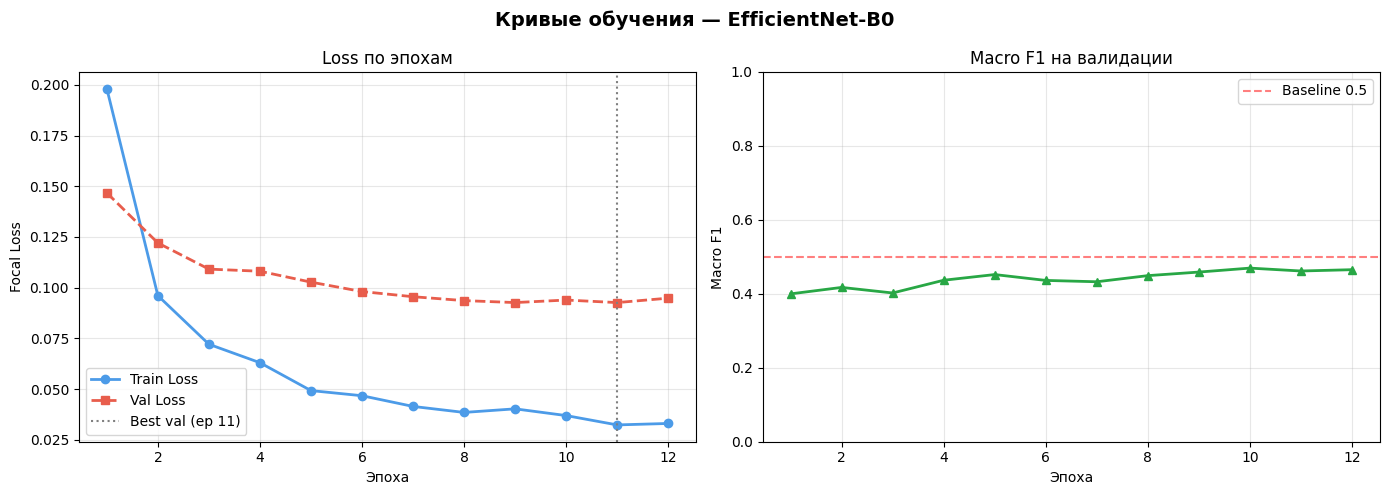

In [ ]:
model_b0, history_b0, preds_b0, labels_b0, metrics_b0 = train_model(
    model_name='efficientnet_b0',
    img_size=224
)

plot_loss_curves(history_b0, 'EfficientNet-B0', save_path='curves_b0.png')

### 15. Обучение EfficientNet-B3


  Обучаем: efficientnet_b3  (вход 300×300)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

efficientnet_b3:   0%|          | 0/12 [00:00<?, ?it/s]

  Ep  1/12 | TrLoss=0.1344 | ValLoss=0.1024 | MacroF1=0.413
  Ep  2/12 | TrLoss=0.0693 | ValLoss=0.0851 | MacroF1=0.447
  Ep  3/12 | TrLoss=0.0519 | ValLoss=0.0764 | MacroF1=0.450
  Ep  4/12 | TrLoss=0.0434 | ValLoss=0.0678 | MacroF1=0.488
  Ep  5/12 | TrLoss=0.0375 | ValLoss=0.0635 | MacroF1=0.490
  Ep  6/12 | TrLoss=0.0319 | ValLoss=0.0606 | MacroF1=0.483
  Ep  7/12 | TrLoss=0.0312 | ValLoss=0.0575 | MacroF1=0.492
  Ep  8/12 | TrLoss=0.0291 | ValLoss=0.0575 | MacroF1=0.495
  Ep  9/12 | TrLoss=0.0275 | ValLoss=0.0564 | MacroF1=0.495
  Ep 10/12 | TrLoss=0.0262 | ValLoss=0.0562 | MacroF1=0.491
  Ep 11/12 | TrLoss=0.0229 | ValLoss=0.0551 | MacroF1=0.504
  Ep 12/12 | TrLoss=0.0262 | ValLoss=0.0548 | MacroF1=0.499
Лучшие веса сохранены в efficientnet_b3_best.pth


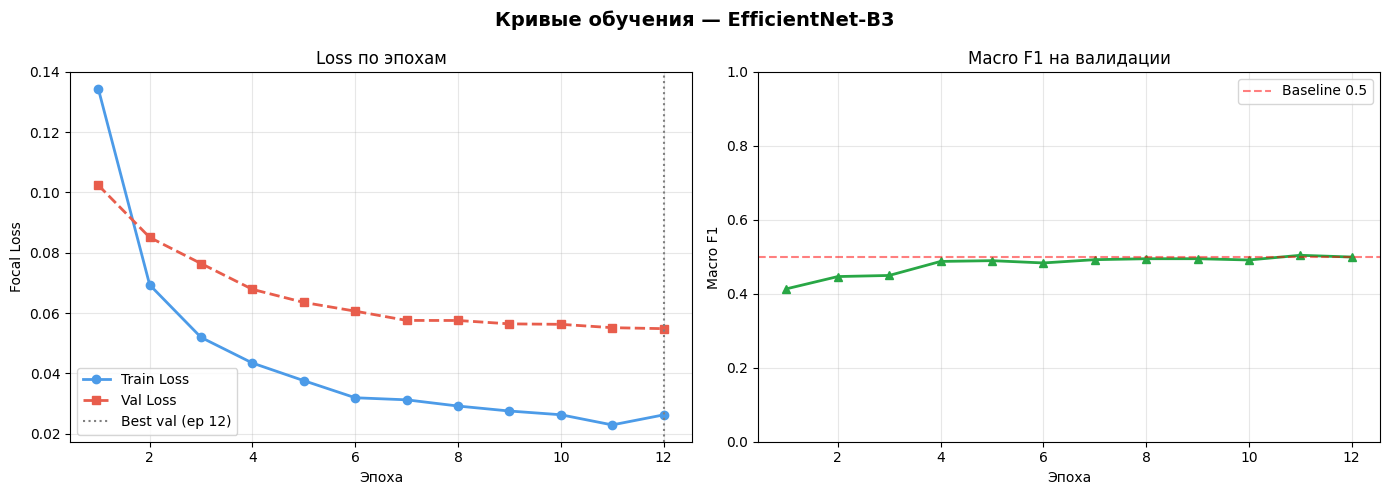

In [ ]:
model_b3, history_b3, preds_b3, labels_b3, metrics_b3 = train_model(
    model_name='efficientnet_b3',
    img_size=300
)

plot_loss_curves(history_b3, 'EfficientNet-B3', save_path='curves_b3.png')

### 16. Делаем сравнительную таблицу метрик

In [ ]:
def build_comparison_table(metrics_b0, metrics_b3):
    rows = []
    for feat in FEATURES:
        m0 = metrics_b0[feat]
        m3 = metrics_b3[feat]
        rows.append({
            'Признак':         m0['name_ru'],
            'Support':         m0['support'],
            'B0 · F1':         round(m0['f1'], 3),
            'B0 · Recall':     round(m0['recall'], 3),
            'B0 · AUC':        round(m0['auc'], 3),
            'B3 · F1':         round(m3['f1'], 3),
            'B3 · Recall':     round(m3['recall'], 3),
            'B3 · AUC':        round(m3['auc'], 3),
        })

    cmp_df = pd.DataFrame(rows)

    macro = {
        'Признак':     'MACRO AVG',
        'Support':     '',
        'B0 · F1':     round(cmp_df['B0 · F1'].mean(), 3),
        'B0 · Recall': round(cmp_df['B0 · Recall'].mean(), 3),
        'B0 · AUC':    round(cmp_df['B0 · AUC'].mean(), 3),
        'B3 · F1':     round(cmp_df['B3 · F1'].mean(), 3),
        'B3 · Recall': round(cmp_df['B3 · Recall'].mean(), 3),
        'B3 · AUC':    round(cmp_df['B3 · AUC'].mean(), 3),
    }
    cmp_df = pd.concat([cmp_df, pd.DataFrame([macro])], ignore_index=True)
    return cmp_df


cmp_df = build_comparison_table(metrics_b0, metrics_b3)


def highlight_best(s):
    col = str(s.name)
    if any(k in col for k in ['F1', 'AUC', 'Recall']):
        numeric = pd.to_numeric(s, errors='coerce')
        is_max = numeric == numeric.max()
        return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]
    return ['' for _ in s]

styled = (
    cmp_df.style
    .apply(highlight_best, axis=0)
    .set_caption('Сравнение EfficientNet-B0 vs B3 , Validation set , threshold=0.4')
    .set_properties(**{'font-size': '12px'})
)
display(styled)

cmp_df.to_csv('comparison_table.csv', index=False)
print("Таблица сохранена в comparison_table.csv")

,Признак,Support,B0 · F1,B0 · Recall,B0 · AUC,B3 · F1,B3 · Recall,B3 · AUC
0,Пигментная сеть,44,0.346000,0.409000,0.616000,0.397000,0.523000,0.674000
1,Полосы (Streaks),56,0.417000,0.518000,0.663000,0.463000,0.554000,0.691000
2,Пигментация,91,0.638000,0.747000,0.677000,0.600000,0.725000,0.629000
3,Регрессия,51,0.358000,0.373000,0.618000,0.384000,0.373000,0.643000
4,Точки/Глобулы,98,0.657000,0.724000,0.667000,0.654000,0.724000,0.692000
5,Бело-голубая вуаль,46,0.450000,0.391000,0.745000,0.566000,0.609000,0.827000
6,Сосудистые структуры,40,0.364000,0.350000,0.723000,0.432000,0.400000,0.764000
7,MACRO AVG,,0.461000,0.502000,0.673000,0.499000,0.558000,0.703000


Таблица сохранена в comparison_table.csv


### 17. Визуализируем метрики

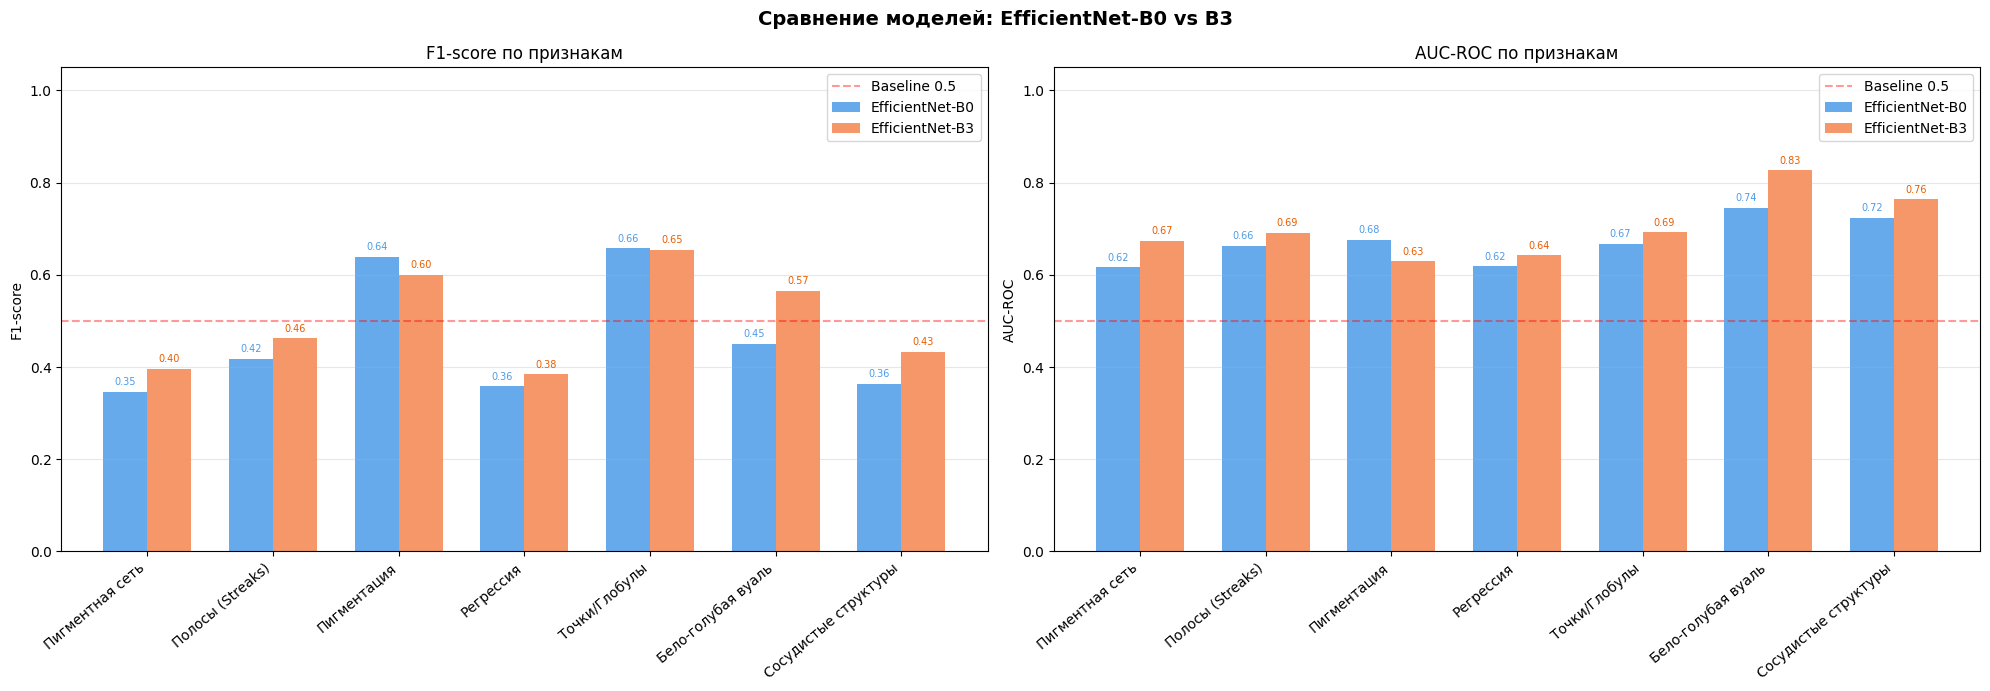

In [ ]:
def plot_metrics_comparison(metrics_b0, metrics_b3, save_path=None):
    metric_key = 'f1'
    f1_b0 = [metrics_b0[f][metric_key] for f in FEATURES]
    f1_b3 = [metrics_b3[f][metric_key] for f in FEATURES]

    auc_b0 = [metrics_b0[f]['auc'] for f in FEATURES]
    auc_b3 = [metrics_b3[f]['auc'] for f in FEATURES]

    x = np.arange(len(FEATURES))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle('Сравнение моделей: EfficientNet-B0 vs B3', fontsize=14, fontweight='bold')

    for ax, vals_b0, vals_b3, ylabel, title in [
        (axes[0], f1_b0, f1_b3, 'F1-score', 'F1-score по признакам'),
        (axes[1], auc_b0, auc_b3, 'AUC-ROC', 'AUC-ROC по признакам'),
    ]:
        bars0 = ax.bar(x - w/2, vals_b0, w, label='EfficientNet-B0', color='#4C9BE8', alpha=0.85)
        bars3 = ax.bar(x + w/2, vals_b3, w, label='EfficientNet-B3', color='#F4854D', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(FEATURE_NAMES_RU, rotation=40, ha='right', fontsize=10)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Baseline 0.5')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)

        # Подписи значений
        for bar in bars0:
            h = bar.get_height()
            if h > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7, color='#4C9BE8')
        for bar in bars3:
            h = bar.get_height()
            if h > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7, color='#E85D00')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_metrics_comparison(metrics_b0, metrics_b3, save_path='metrics_comparison.png')

### 18. Confusion Matrix

EfficientNet-B0


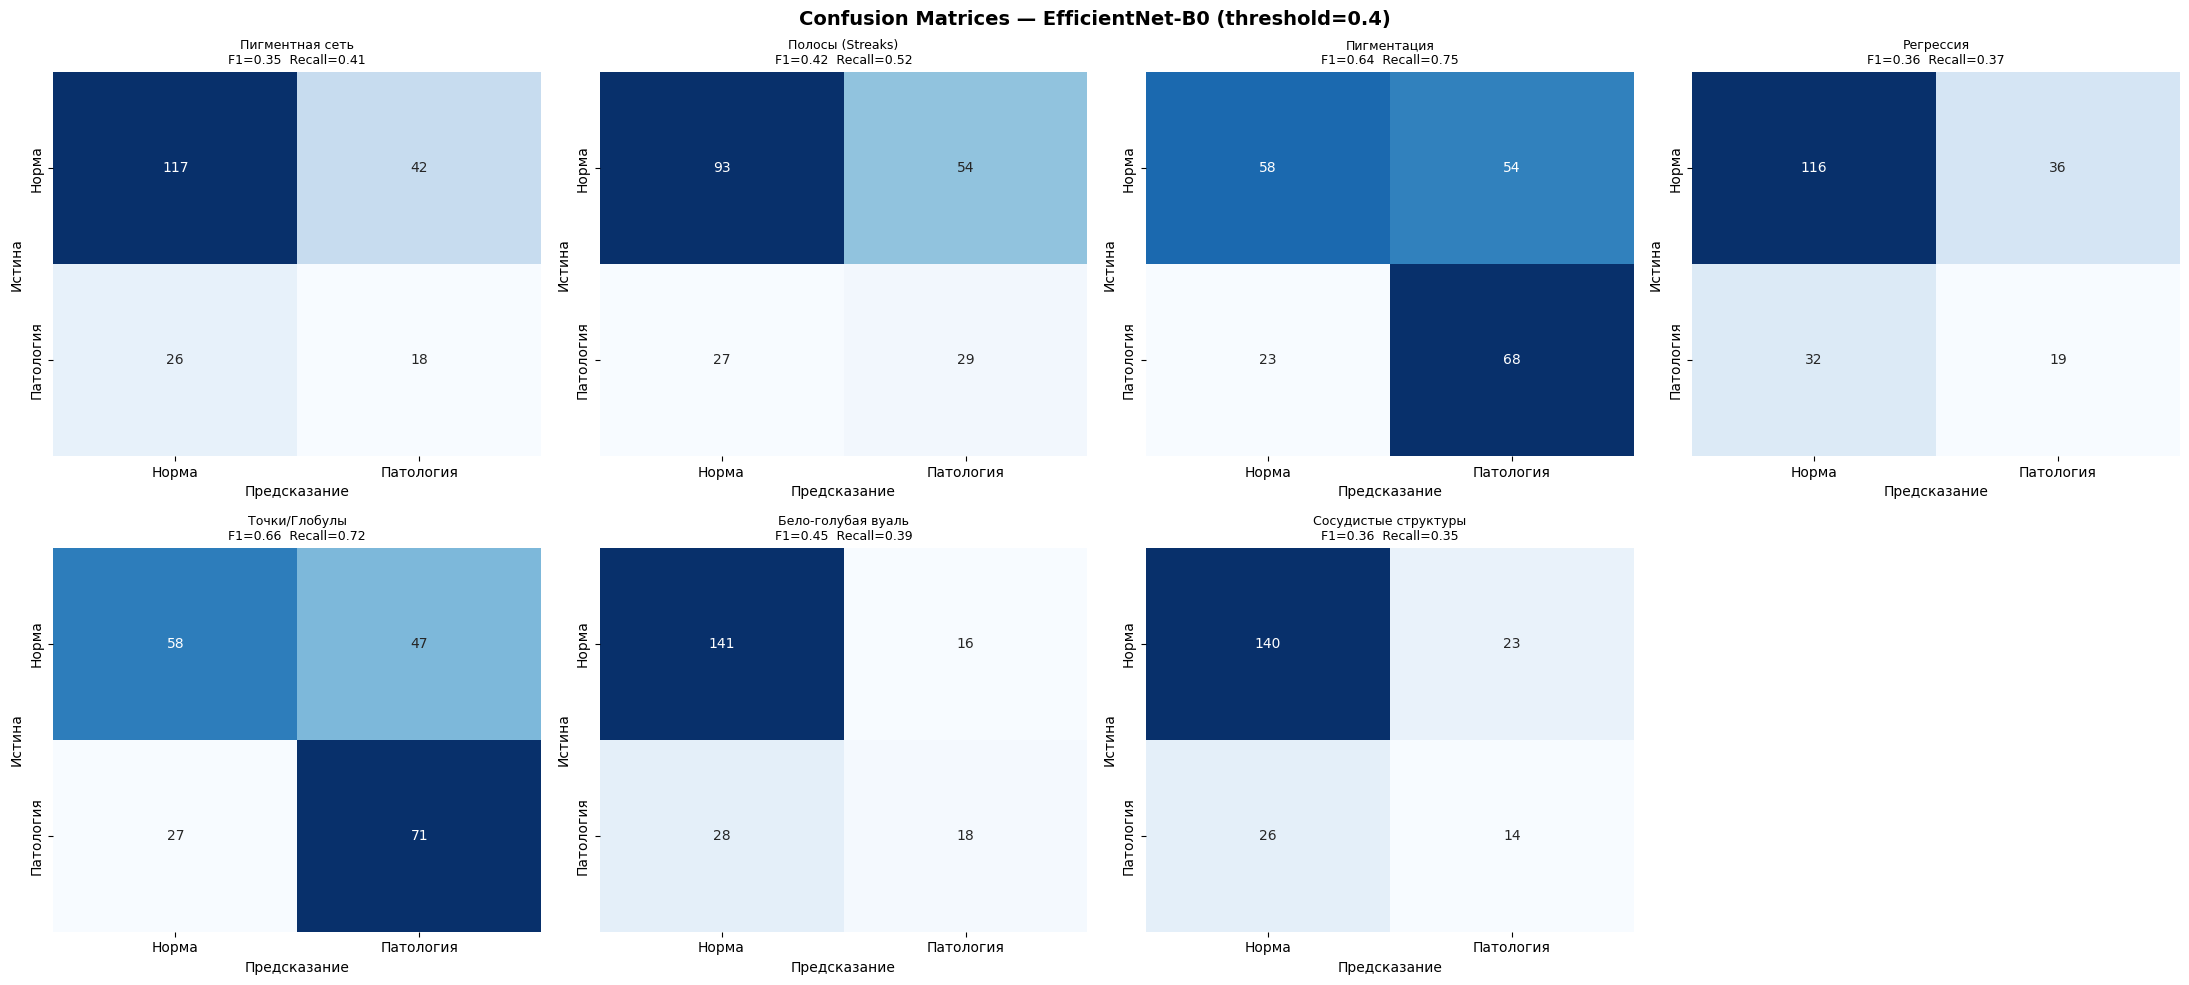

EfficientNet-B3


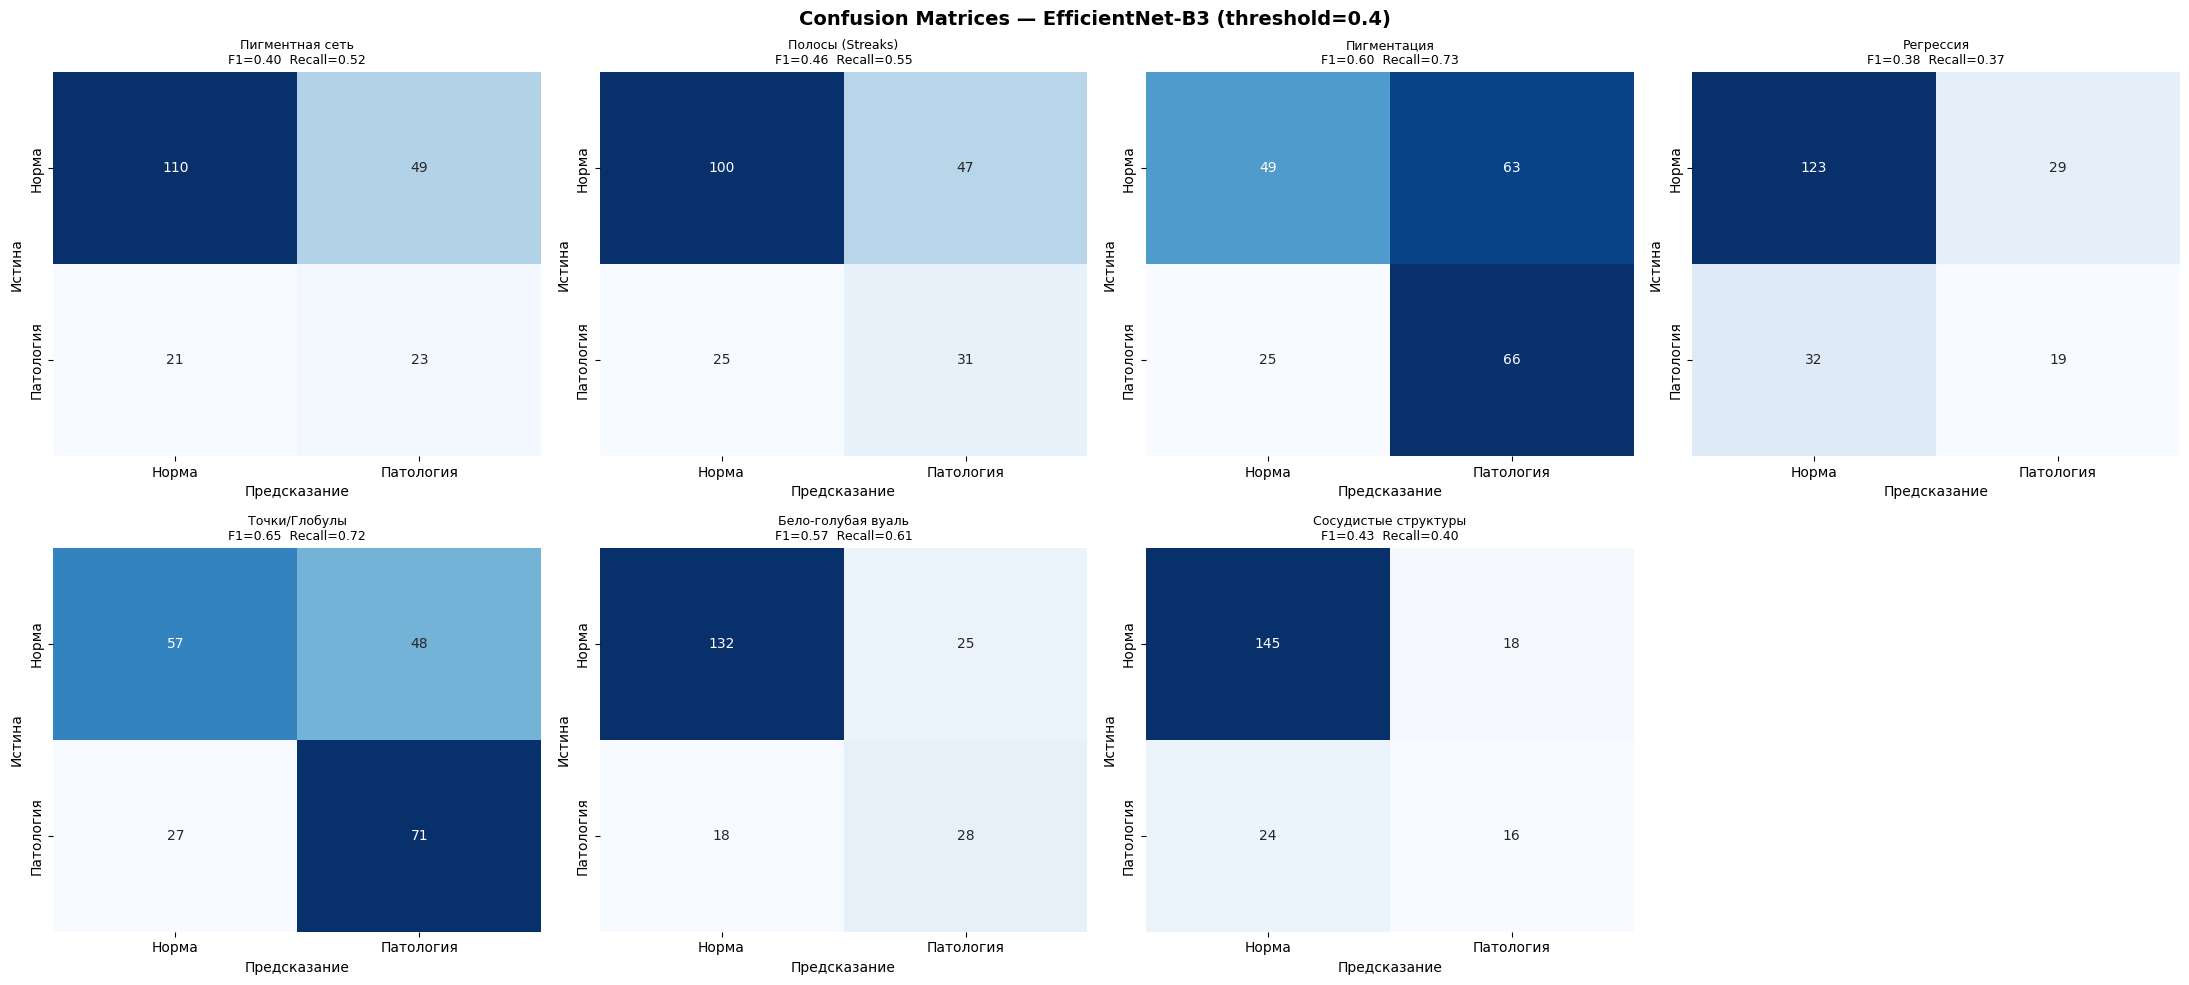

In [ ]:
print("EfficientNet-B0")
plot_confusion_matrices(preds_b0, labels_b0, 'EfficientNet-B0', save_path='cm_b0.png')

print("EfficientNet-B3")
plot_confusion_matrices(preds_b3, labels_b3, 'EfficientNet-B3', save_path='cm_b3.png')

### 19. Grad-CAM

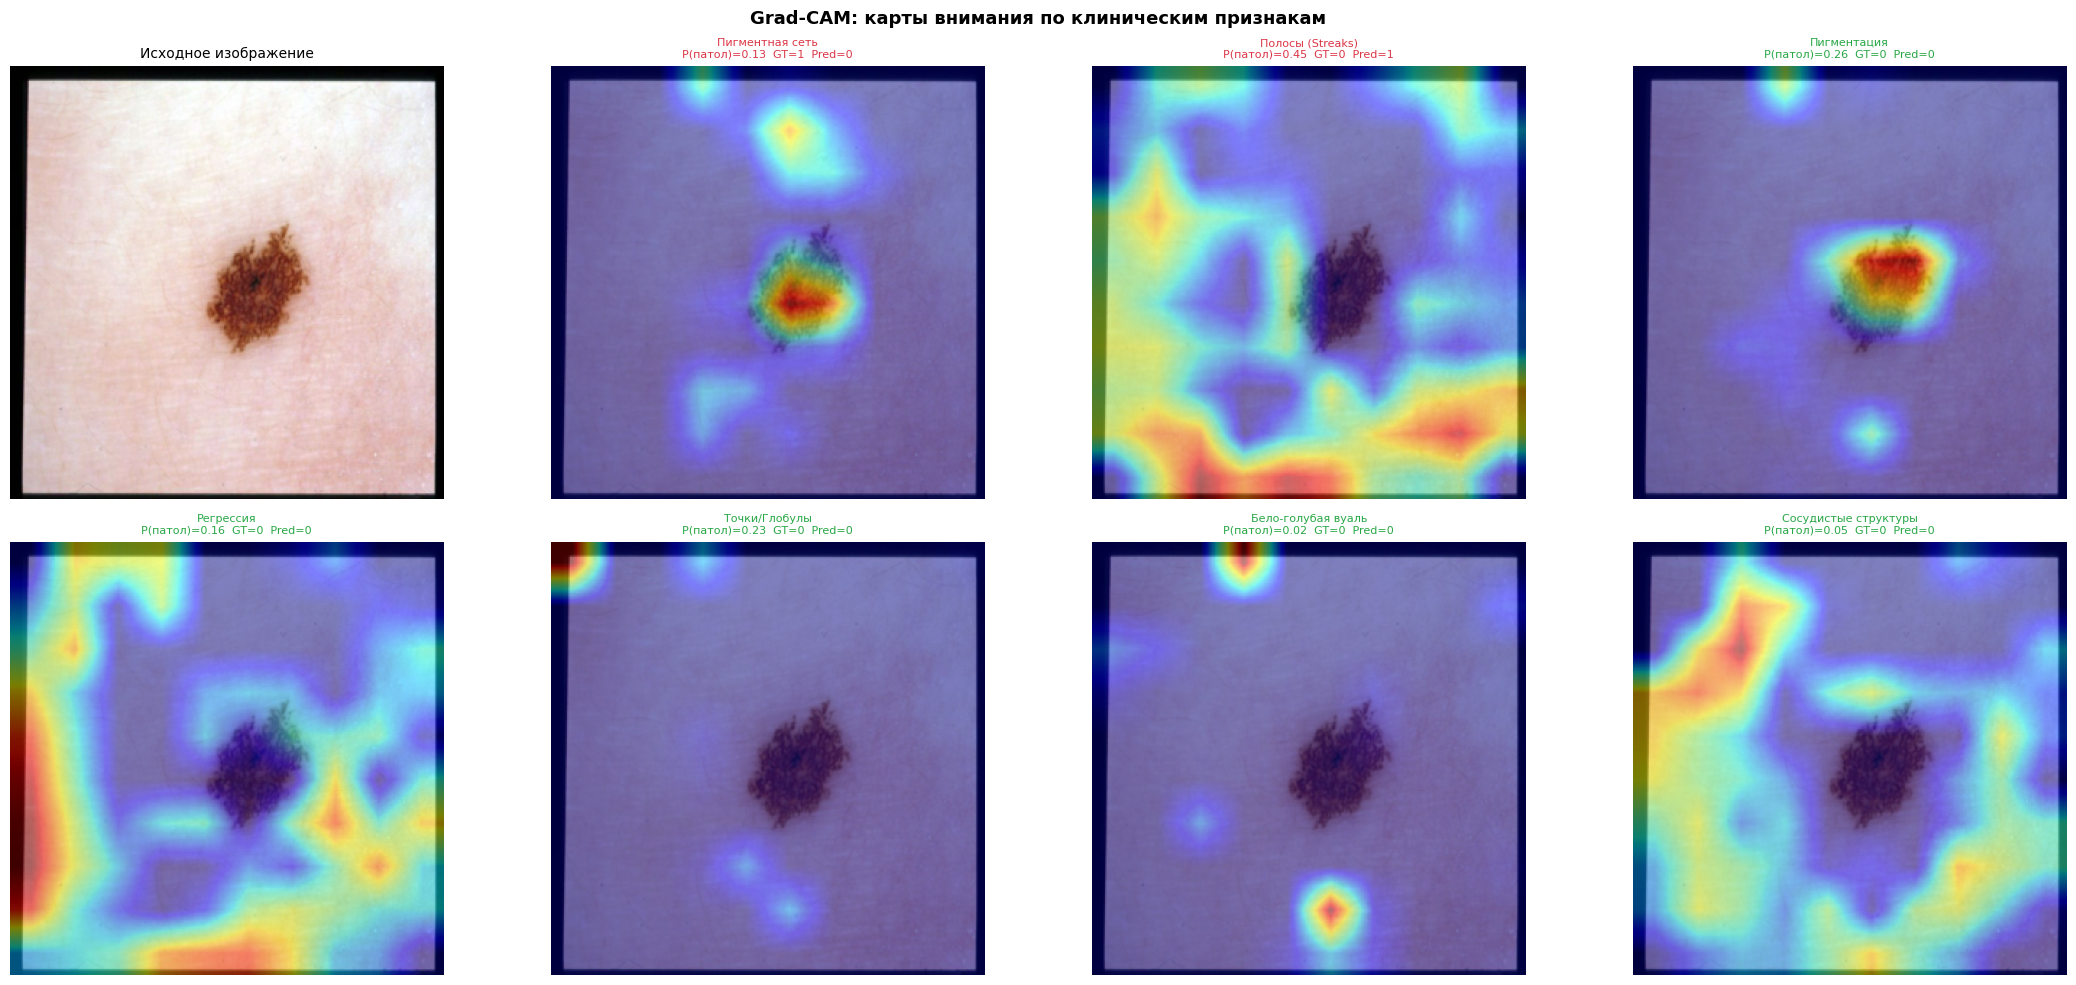

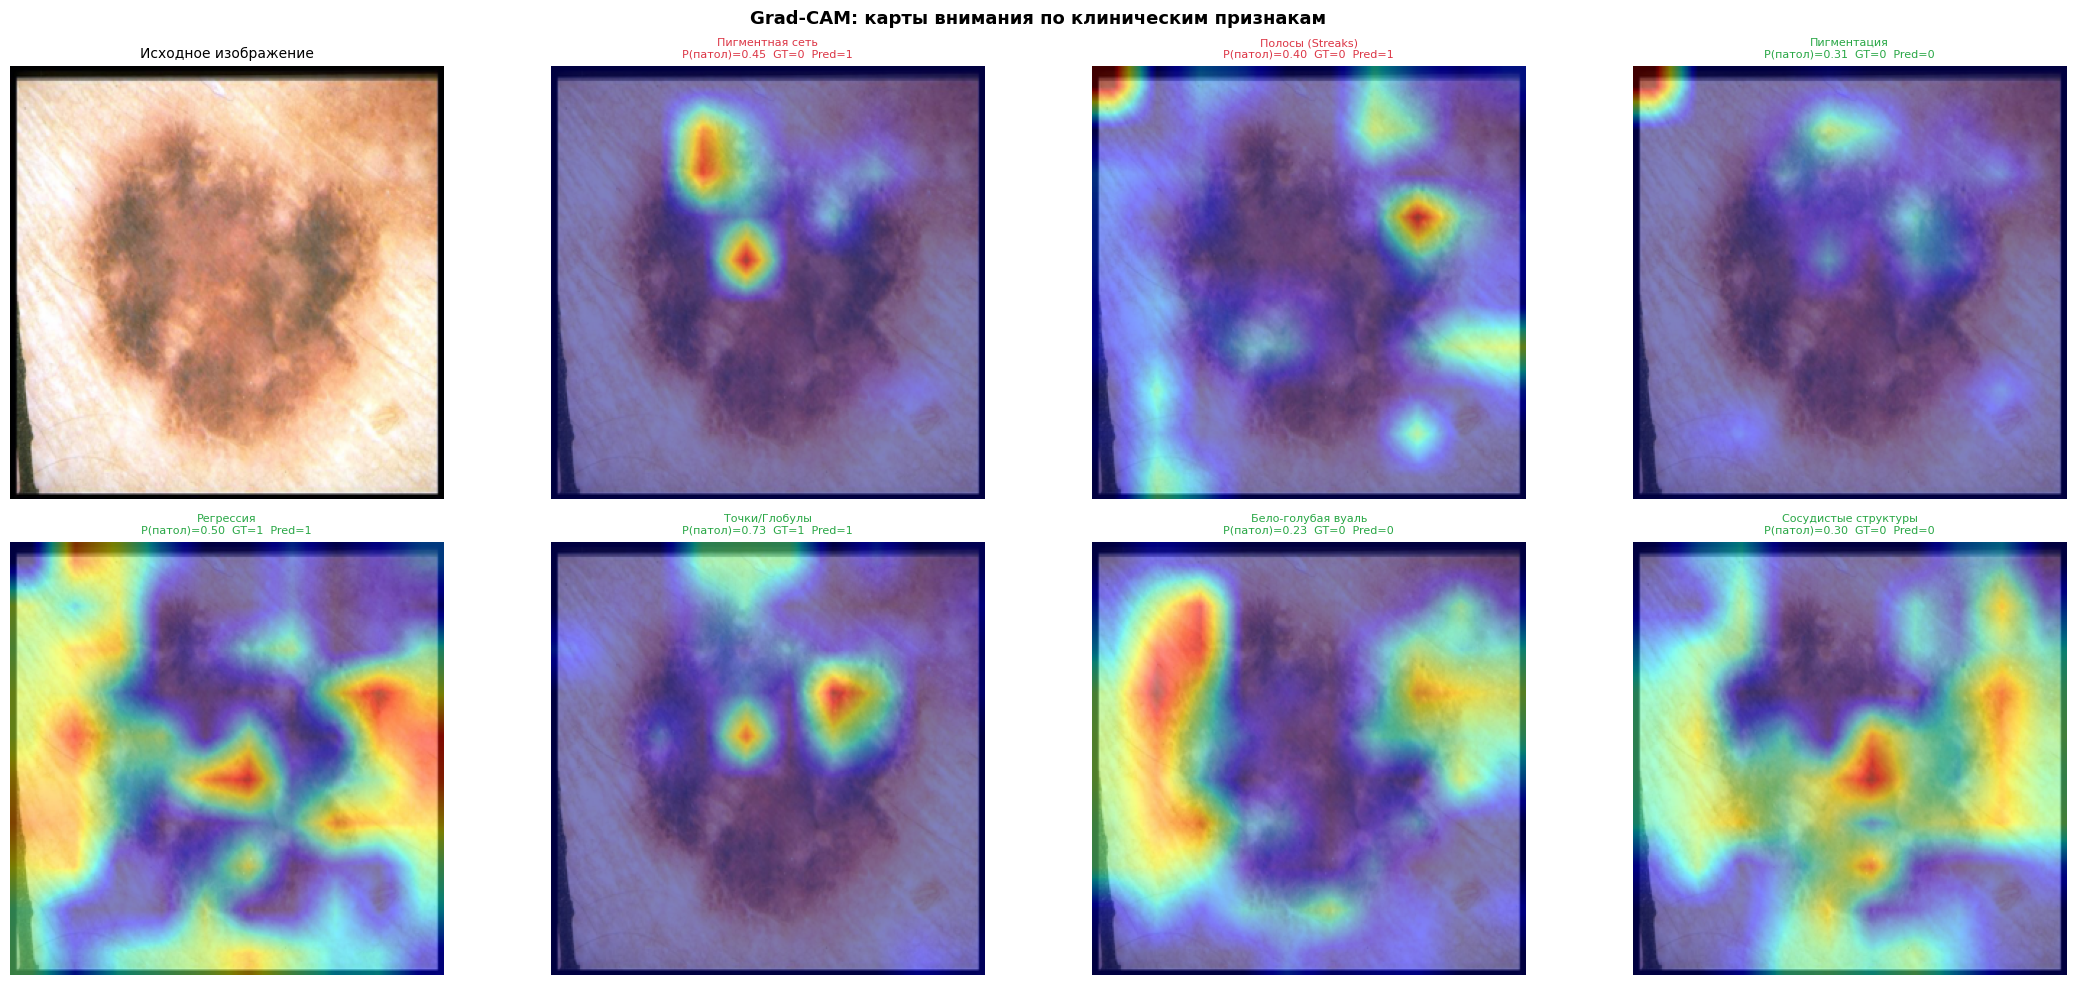

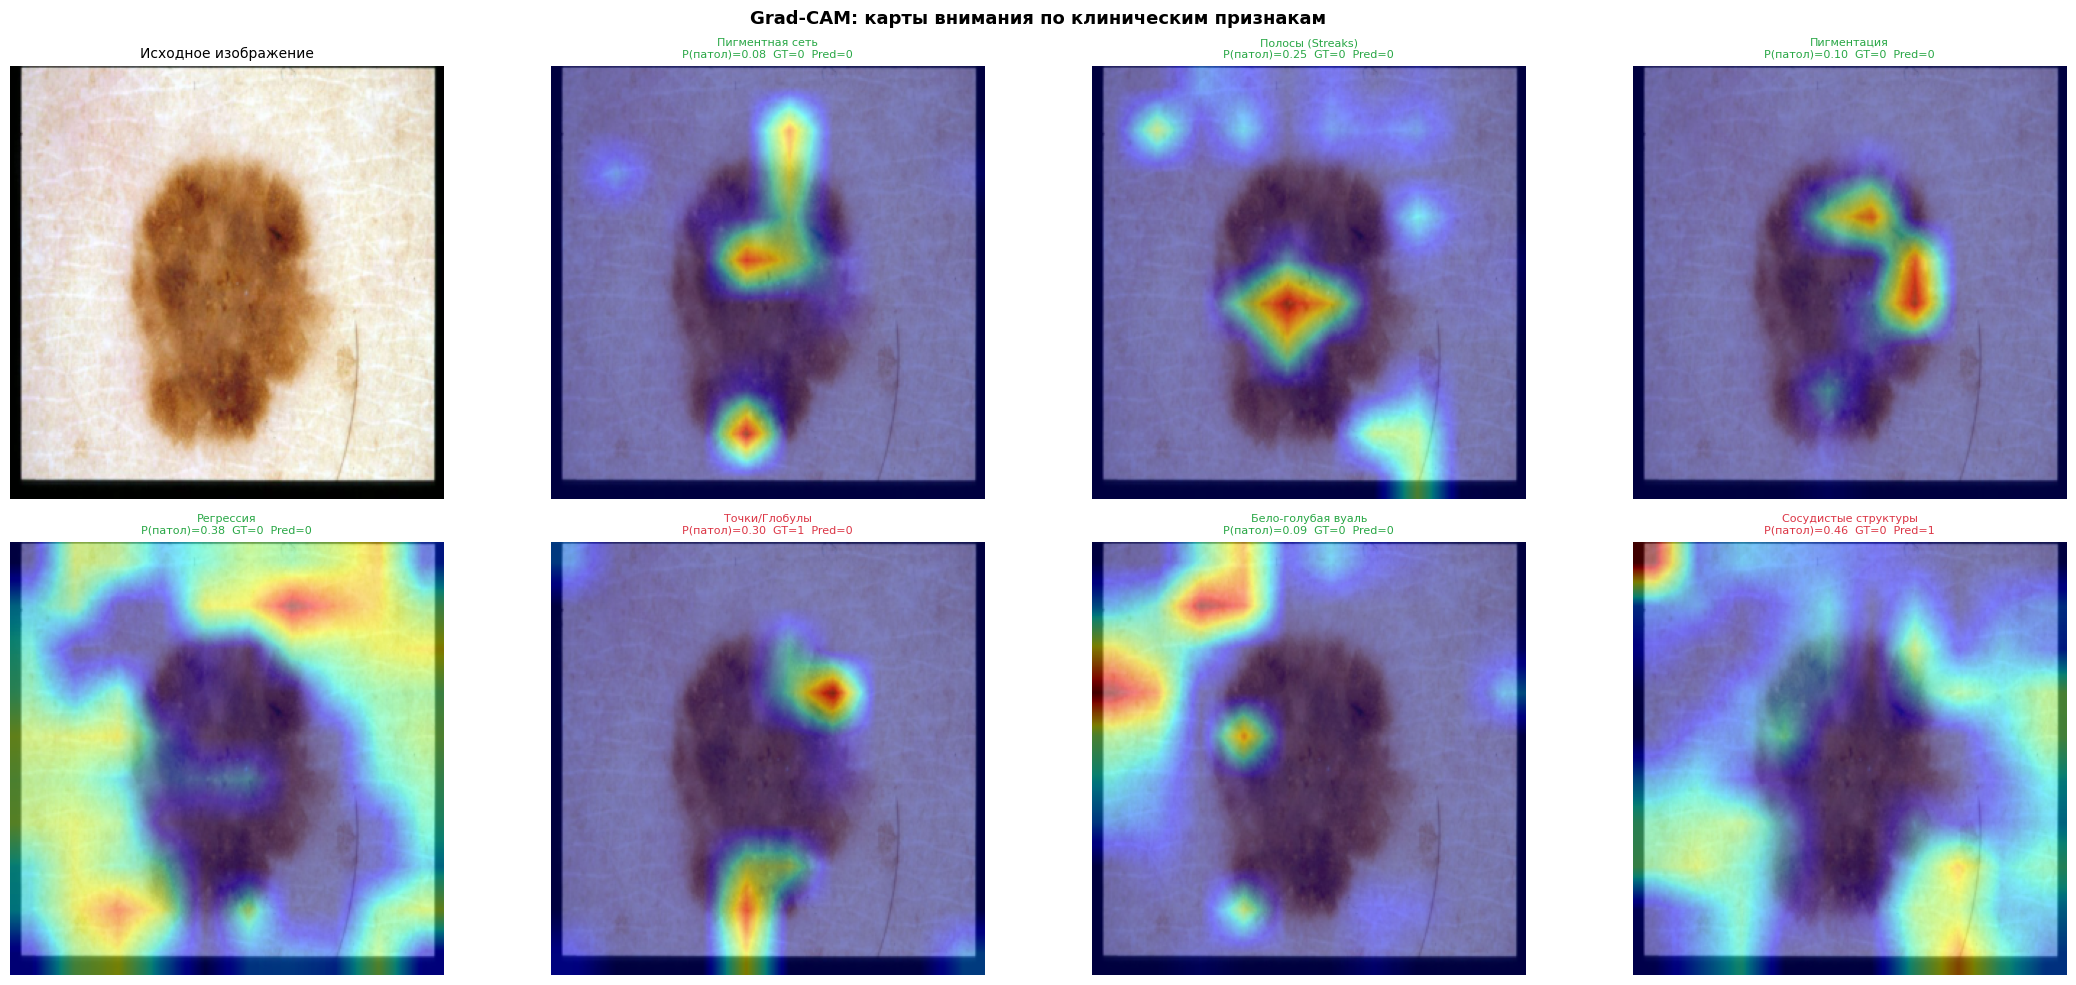

In [ ]:
model_b3.eval()
plot_gradcam(
    model=model_b3,
    model_name='efficientnet_b3',
    val_df=val_df,
    n_samples=3,
    save_path='gradcam_b3.png'
)

### 20. Вывод

Модель EfficientNet-B3 продемонстрировала более высокую обобщающую способность, показав лучшие результаты в детектировании критических признаков: "Бело-голубая вуаль" и "Сосудистые структуры".

Внедрение функции потерь Focal Loss позволило предотвратить игнорирование моделью редких патологических признаков, обеспечив стабильное обучение на выборке малого объема (413 изображений).

Снижение порога классификации до 0.4 позволило максимизировать метрику Recall, что является приоритетным в медицинской диагностике для минимизации риска пропуска злокачественных новообразований.

Предварительные карты внимания Grad-CAM подтверждают фокус модели на клинически значимых зонах поражения, что решает проблему "черного ящика" и повышает доверие врача к системе.